# Week 8 - Multivariate Analysis

## Please run the cells of the notebook as you get to them while reading

In [34]:
import pandas as pd
import numpy as np
from datetime import datetime, timedelta
import seaborn as sns
from sklearn import decomposition
from sklearn import linear_model
from sklearn import metrics
import matplotlib.pyplot as plt
from sklearn.metrics import mean_squared_error

# 1. Lesson: Multivariate graphs

In this lesson, we'll consider some multivariate plots: heatmaps and bubble plots.  We'll also consider principal component analysis and multiple regression.

### Heatmaps

In this plot, we use a heatmap to count the total traffic tickets given to citizens.  A heatmap requires the x and y axes to be categorical, while the color involves a third, numerical variable.  In this example, each row of the DataFrame represents a traffic ticket given to one person in a particular city and year.  The data are given as three columns (city, year, and ticket), so we must use a pivot_table to transform it into a two-dimensional grid.  The cmap is set to "Blues" in the first example, meaning that the heatmap uses only blue as its color.  However, we could also use a multicolor map like "viridis" in the second example.  I personally think "Blues" is easier to read - what do you think?  Here is a reference guide to the color maps:

https://matplotlib.org/stable/gallery/color/colormap_reference.html

In [2]:
np.random.seed(0)
num_samples = 100
city_series = np.random.choice(["New York", "Boston", "Atlanta", "Washington, D. C."], size = num_samples)
year_series = np.random.choice([2018, 2019, 2020], size = num_samples)
ticket_series = np.random.randint(50, 150, size = num_samples) # Traffic tickets can be from $50 to $150
df = pd.DataFrame({"city": city_series, "year": year_series, "ticket": ticket_series})
pivot = df.pivot_table(index = ["city"], columns = ["year"], values = "ticket", aggfunc = "sum")

In [3]:
df.iloc[0:5] # first five rows of a long DataFrame

,city,year,ticket
0,New York,2019,79
1,"Washington, D. C.",2020,71
2,Boston,2018,75
3,New York,2018,130
4,"Washington, D. C.",2020,110


In [4]:
pivot # 2 by 2 grid showing total ticket amounts

year,2018,2019,2020
city,,,
Atlanta,742,440,538
Boston,775,628,922
New York,1122,841,596
"Washington, D. C.",1258,451,1385


Text(0.5, 1.0, 'Total traffic tickets by city and year')

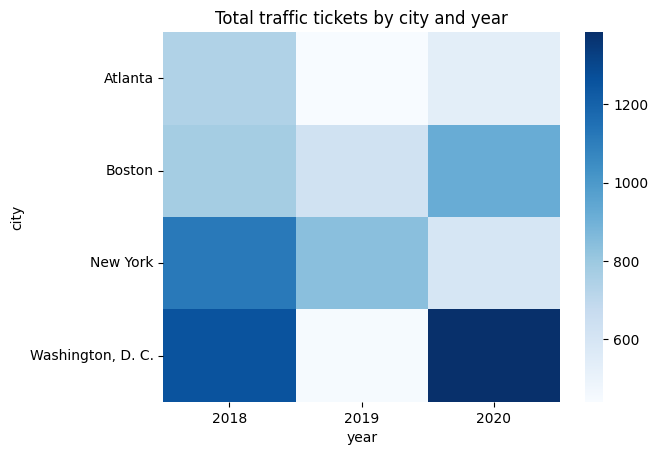

In [5]:
ax = sns.heatmap(pivot, cmap = "Blues")
ax.set_title("Total traffic tickets by city and year")

Text(0.5, 1.0, 'Average traffic ticket value by city and year')

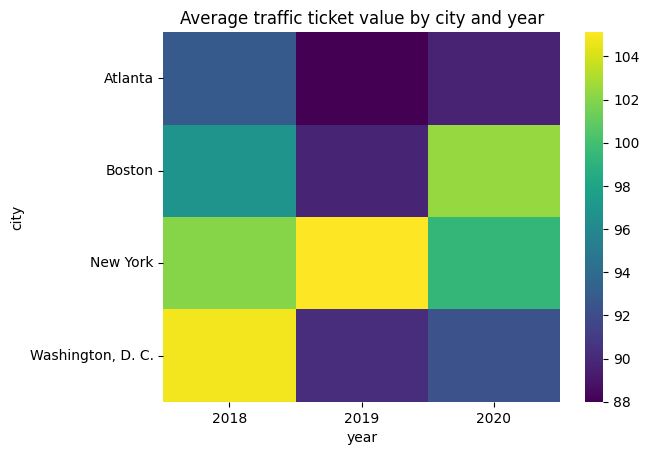

In [6]:
pivot2 = df.pivot_table(index = ["city"], columns = ["year"], values = "ticket", aggfunc = "mean") # note mean, not sum this time
ax2 = sns.heatmap(pivot2, cmap = "viridis") # do you think this is a better or worse scale than Blues?
ax2.set_title("Average traffic ticket value by city and year")

### Bubble plots

A bubble plot is just a scatter plot, but with the dot size representing a third variable.  Here, each data point shows a tree (I mean the kind of tree that is a plant and grows in the ground, not a decision tree), with its height, width of branches, and root depth.  The bubble size in the bubble plot represents the root depth, while the other variables are shown on the x and y axes.  From this plot, we can see that the root depth is strongly correlated with both the width of branches and the tree height.

Text(0, 0.5, 'width of branches')

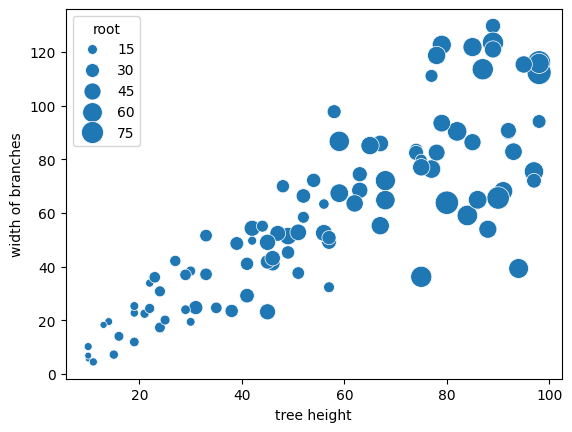

In [7]:
np.random.seed(0)
num_samples = 100
height_series = np.random.randint(10, 100, size = num_samples) # tree height
width_series = height_series * np.maximum(np.random.normal(scale = 0.3, loc = 1, size = num_samples), 0.25) # strongly related to height
root_series = height_series * np.maximum(np.random.normal(scale = 0.2, loc = 0.7, size = num_samples), 0.3) # strongly related to height
df2 = pd.DataFrame({'height': height_series, 'width': width_series, 'root': root_series})
minroot = root_series.min()
maxroot = root_series.max()
maxbubble = 300
ax = sns.scatterplot(data = df2, x = "height", y = "width", size = "root", sizes = (minroot / maxroot * maxbubble, maxbubble))
ax.set_xlabel("tree height")
ax.set_ylabel("width of branches")

### Principal Component Analysis

Principal Component Analysis can be thought of as a way to use one (or a few) linear combinations of the coordinates in order to explain all of the coordinates.  It is most useful when there are strong correlations between some or all of the coordinates.  Principal Component Analysis can show us which linear combinations are most (and least) useful for explaining the data.

With the trees data, the three values (height, width, and root) are highly correlated.  For this reason, Principal Component Analysis shows that most of the variance can be explained by a single value which is a linear combination of height, width, and root.  What this means is that if the first components_ vector in the code below (the "first principal component") is \[a, b, c\], for some specific numbers a, b, and c, then the value v = a * (height - mu_h) + b * (width - mu_w) + c * (root - mu_r), where the mu's are the means, is highly informative about the values of height, width, and root.  In this case, because height, width, and root are so highly correlated, we can almost assume that all of the data is located along an axis defined by the vector \[a, b, c\].  The point v * \[a, b, c\] + (mean vector) = (a * (height - mu_h) + b * (width - mu_w) + c * (root - mu_r)) * \[a, b, c\] + (mean vector) is therefore approximately equal to the data point (height, width, root) in question.  The mean vector is \[mu_h, mu_w, mu_r\].  Importantly, there is still variance unexplained by this one value - just knowing v * \[a, b, c\] does not tell you the height, width, and root with 100% accuracy.  If the second principal component is \[d, e, f\], then we could approximate the tree vector even more accurately as: (height, width, root) = (a * (height - mu_h) + b * (width - mu_w) + c * (root - mu_r)) * \[a, b, c\] + (d * (height - mu_h) + e * (width - mu_w) + f * (root - mu_r)) * \[d, e, f\] + (mean vector).

The printing of "components_", below, shows the first principal component \[a, b, c\].  If you draw a vector in the direction shown, you will be heading in the direction where the values height, width, and root change most rapidly.  A later computation shows all three principal component vectors.

**Optional exercise for the reader:** show that if all three principal components are included, then equality is exact.  This is going to be true simply because the principal components are orthonormal: the projections onto a complete set of orthonormal vectors always add up to the original vector.

(height, width, root) = (a * (height - mu_h) + b * (width - mu_w) + c * (root - mu_r)) * \[a, b, c\] + (d * (height - mu_h) + e * (width - mu_w) + f * (root - mu_r)) * \[d, e, f\] + (g * (height - mu_h) + h * (width - mu_w) + i * (root - mu_r)) * \[g, h, i\] + \[mu_h, mu_w, mu_r\].

For this proof, we must use the fact that the principal component vectors are orthonormal.  That is, any pair of them are orthogonal, even with a transpose (ad + be + cf = 0, ag + bh + ci = 0, dg + eh + fi = 0, ab + de + gh = 0, ac + df + gi = 0, bc + ef + hi = 0) and any one of them is a unit vector, even with a transpose (a^2 + b^c + c^2 = 1, d^2 + e^2 + f^2 = 1, g^2 + h^2 + i^2 = 1, a^2 + d^2 + g^2 = 1, b^2 + e^2 + h^2 = 1, c^2 + f^2 + i^2 = 1).  If you write out the equation above as a single vector, then apply the orthonormality rules, you should be able to prove equality.

In [8]:
pca = decomposition.PCA(n_components = 1)
pca.fit(df2)
print(f"The first principal component explains {pca.explained_variance_ratio_[0]} of the variance")
print(f"The components_ vector is [a, b, c] = {pca.components_}")
mu_h, mu_w, mu_r = df2.mean().values
print(f"(height, width, root) is approximately equal to ({pca.components_[0][0]:.2} * (height - {mu_h:.2}) + {pca.components_[0][1]:.2} * (width - {mu_w:.2}) + {pca.components_[0][2]:.2} * (root - {mu_r:.2})) * ({pca.components_[0][0]:.2}, {pca.components_[0][1]:.2}, {pca.components_[0][2]:.2}) + ({mu_h:.2}, {mu_w:.2}, {mu_r:.2})")
print("Examples: (estimating the the vector equals its projection onto the first principal component)")
df_example = df2.copy()
df_example["v"] = pca.components_[0][0] * (df2["height"] - mu_h) + pca.components_[0][1] * (df2["width"] - mu_w) + pca.components_[0][2] * (df2["root"] - mu_r)
df_example["height_est"] = df_example["v"] * pca.components_[0][0] + mu_h
df_example["width_est"] = df_example["v"] * pca.components_[0][1] + mu_w
df_example["root_est"] = df_example["v"] * pca.components_[0][2] + mu_r
print(df_example.iloc[0:5])
print("Means:")
print(f"mu_h = {mu_h:.3}", f"mu_w = {mu_w:.3}", f"mu_r = {mu_r:.3}")

The first principal component explains 0.8686108480944678 of the variance
The components_ vector is [a, b, c] = [[0.59031629 0.71908728 0.36666083]]
(height, width, root) is approximately equal to (0.59 * (height - 5.6e+01) + 0.72 * (width - 5.9e+01) + 0.37 * (root - 3.6e+01)) * (0.59, 0.72, 0.37) + (5.6e+01, 5.9e+01, 3.6e+01)
Examples: (estimating the the vector equals its projection onto the first principal component)
   height       width       root          v  height_est  width_est   root_est
0      54   72.139334  31.517932   6.287751   60.001762  63.563941  38.673095
1      57   49.169527  33.768693  -7.633330   51.783921  53.553468  33.568780
2      74   83.443733  28.770850  25.215680   71.175227  77.174773  45.613225
3      77   76.353866  53.061241  30.794730   74.468631  81.186597  47.658844
4      77  111.095365  26.006307  45.856916   83.360084  92.017624  53.181557
Means:
mu_h = 56.3 mu_w = 59.0 mu_r = 36.4


If we were to choose a second or third component to preserve, that values below show that each would explain a small, additional amount of the variance.  This means that with this particular dataset, we should likely do PCA using only one component and not two.  If the components' explained variances were closer in magnitude to each other, we might have to include two or even all three values to explain the data.

In [9]:
pca3 = decomposition.PCA(n_components = 3)
pca3.fit(df2)
print(pca3.explained_variance_ratio_)
print(pca3.components_)

[0.86861085 0.09414617 0.03724298]
[[ 0.59031629  0.71908728  0.36666083]
 [ 0.32633701 -0.62809127  0.70640322]
 [ 0.73826204 -0.29734633 -0.6054373 ]]


The principal component vectors shown are orthogonal to each other (their dot product is basically zero).  Here, we check that using the first two vectors.

In [11]:
print(np.array(pca3.components_[0]).dot(np.array(pca3.components_[1])))

5.551115123125783e-17


We can use the projection onto the first principal component as if it were a new feature.  For instance, we could plot a histogram of the data against the magnitude of the projection onto the first principal component.  In fact, for some purposes, this magnitude (which we have called v) might make a better feature for data analysis than either height, width, or root.  We must subtract off the mean before the dot product; the understanding is that this represents the component of the data relative to the mean.

<Axes: >

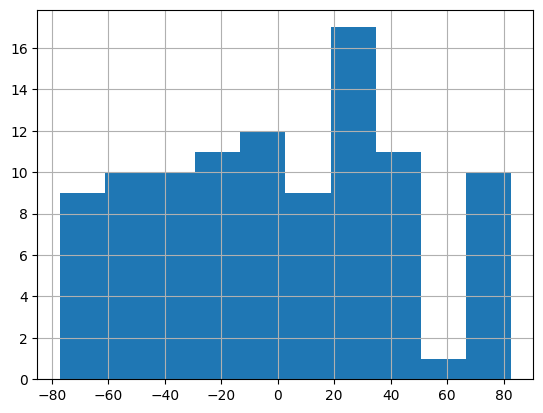

In [12]:
((df2 - df2.mean()).dot(np.array(pca.components_[0]))).hist()

In [13]:
# Showing that this is the same as the value we've called "v"
(df_example["v"] - (df2 - df2.mean()).dot(np.array(pca.components_[0]))).max()

np.float64(1.4210854715202004e-14)

### Linear Regression

Now let's run a linear regression model to predict the root from the height and width, as well as predicting the third principal component from the first and second.  Which is easier to predict?

### Predicting the root from the height and width

In [14]:
linreg = linear_model.LinearRegression()
linreg.fit(df2[['height', 'width']], df2['root'])
preds = linreg.predict(df2[['height', 'width']])
metrics.mean_squared_error(preds, df2['root']) # Mean squared error as a metric

138.22487356329611

In [15]:
np.corrcoef(preds, df2['root']) # Correlation coefficient as a metric

array([[1.        , 0.79468295],
       [0.79468295, 1.        ]])

### Predicting the third principal component from the first and second

In [16]:
first_principal_component_score = (df2 - df2.mean()).dot(np.array(pca3.components_[0]))
second_principal_component_score = (df2 - df2.mean()).dot(np.array(pca3.components_[1]))
third_principal_component_score = (df2 - df2.mean()).dot(np.array(pca3.components_[2]))

In [17]:
linreg_first = linear_model.LinearRegression()
pc_X = np.array([first_principal_component_score, second_principal_component_score]).T
linreg_first.fit(pc_X, third_principal_component_score)
preds = linreg_first.predict(pc_X)
metrics.mean_squared_error(preds, third_principal_component_score) # The mean squared error is a bit smaller here.

78.74928905273174

In [18]:
np.corrcoef(preds, third_principal_component_score) # More importantly, the correlation is basically zero

array([[1.00000000e+00, 1.89578845e-15],
       [1.89578845e-15, 1.00000000e+00]])

Here, we see that the projections of the first two principal components have no ability to predict the projection of the third, when measured by correlation.  This is a special property of principal components.  It is intended to ensure that the each component gives new information not present in the previous components.

The mean_squared_error is misleading - it makes it look like the error is less for the second computation than the first; but the correlation coefficient is giving more useful information here.  We cannot compare the mean squared error for two totally different computations, because mean squared error is highly dependent on the magnitudes of the values in question!

# 2. Weekly graph question

The tree data above can be graphed via either a pairplot or a bubble plot.  What are the advantages and disadvantages of each?

### Answer
#### Bubble advantages:
The bubble plot visually encodes the three variables in a 2D plot using x and y positions, and bubble size. In the tree dataset, the height is on the x axis, width on the y axis, and root depth is encoded by the size of the bubble. This allows us to see how all three variables interact. For example, we see that larger trees (higher on the x and y axes) tend to have deeper roots (larger bubbles). It's a compact and intuitive way to show correlation and scale at the same time. it's useful when a variable like root depth can be interpreted as a magnitude or "impact" on the others.

#### Bubble disadvantages:
Bubble plots become hard to interpret when there are data points that overlap or cluster closely, especially with varying bubble sizes. Since the bubble area represents the third variable, our perceptions can struggle to figure out the magnitude differences properly. This makes comparing root depth between nearby bubbles less easy than a numerical label or color scale. also, bubble plots only show the relationship between two variables plus one magnitude, meaning interactions between all three variables pairwise (like root vs. width) have to be be inferred or plotted separately.

#### Pairplot avantages:
The pairplot displays every pairwise combination of numeric features in thetree dataset using scatterplots and histograms. For the dataset, it produces height vs. width, height vs. root, and width vs. root all in one grid. This gives us a comprehensive overview of each bivariate relationship across all features, helping us identify strong correlations, clusters, and outliers. It’s great for exploratory analysis and finding linear/nonlinear relationships between variables quickly.

#### Pairplot disadvantages:
Pairplots are visually overwhelming and not really pleasing to look at, especially with more than 3–4 variables or large sample sizes. Each scatterplot in the matrix can only handle two variables at a time, and it doesn't account for a third variable like the bubble plot does. This means we lose information about the combined influence of all three variables at once. Additionally, with a small dataset like this, pairplots seem visually repetitive, offering less insight than a more focused 3-variable plot like the bubble plot.

Text(0, 0.5, 'width of branches')

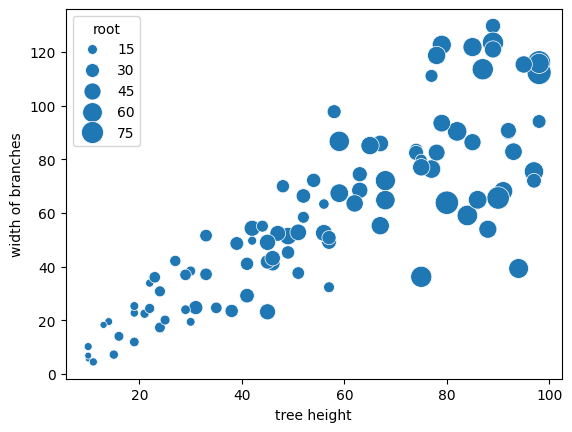

In [19]:
ax = sns.scatterplot(data = df2, x = "height", y = "width", size = "root", sizes = (minroot / maxroot * maxbubble, maxbubble))
ax.set_xlabel("tree height")
ax.set_ylabel("width of branches")

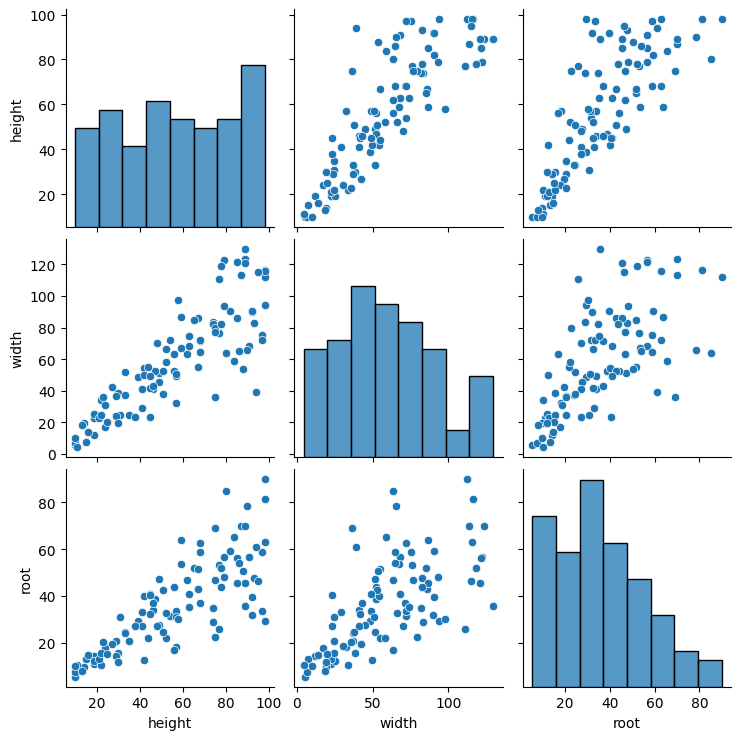

In [20]:
sns.pairplot(df2)

# 3. Homework - Grocery Store Correlation

In a particular state, the price of milk is highly correlated with the price of cheese.  Neither is correlated with the price of bread.

In [24]:
num_points = 1000
np.random.seed(0)
milk_series = np.maximum(np.random.normal(scale = 0.5, loc = 2.00, size = num_points), 1)
cheese_series = milk_series * np.maximum(np.random.normal(scale = 0.1, loc = 1.00, size = num_points), 0.5)
bread_series = np.maximum(np.random.normal(scale = 1.0, loc = 3.00, size = num_points), 1)
df3 = pd.DataFrame({"milk": milk_series, "cheese": cheese_series, "bread": bread_series})

### Heatmap

Draw a heatmap where the x-axis category is a discretized version of the milk price and the y-axis category is a discretized version of the cheese price.  That is, you can choose "low", "medium", and "high" for the milk price, or, if you prefer, you can choose 1, 2, 3, 4, and 5 for the five quintiles.  (The first quintile should include the bottom fifth of the data, the second quintile contains the next fifth, and so on).

Try Googling "how do I change numerical to categorical data" to get advice on this.

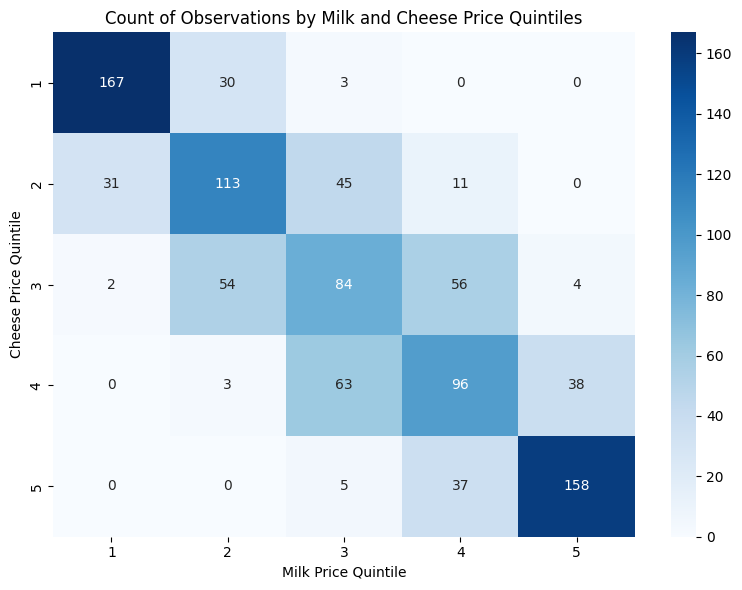

In [28]:
# turn it into quintiles
df3["milk_quintile"] = pd.qcut(df3["milk"], q=5, labels=[1, 2, 3, 4, 5])
df3["cheese_quintile"] = pd.qcut(df3["cheese"], q=5, labels=[1, 2, 3, 4, 5])

# pivot table to count tje occurrences
pivot = df3.pivot_table(index="cheese_quintile", columns="milk_quintile", values="bread", aggfunc="count", observed=False)

# plot the heatmap
plt.figure(figsize=(8, 6))
ax = sns.heatmap(pivot, cmap="Blues", annot=True, fmt="d")
ax.set_title("Count of Observations by Milk and Cheese Price Quintiles")
ax.set_xlabel("Milk Price Quintile")
ax.set_ylabel("Cheese Price Quintile")
plt.tight_layout()
plt.show();

### Bubble plot

Try all three possible bubble plots: one where the size of the dot is determined by the milk price, one where it's the cheese price, and one where it's the bread price.  Which of these plots is / are the most informative and useful?

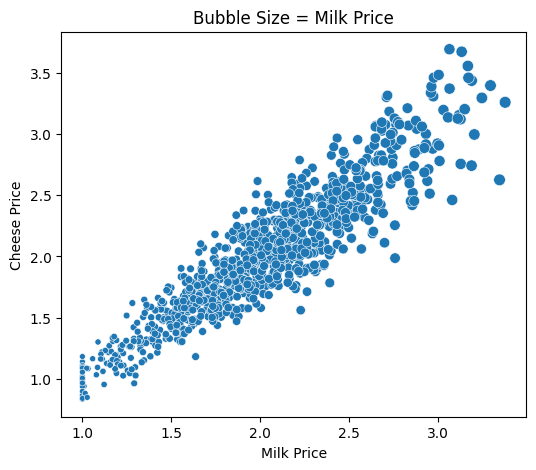

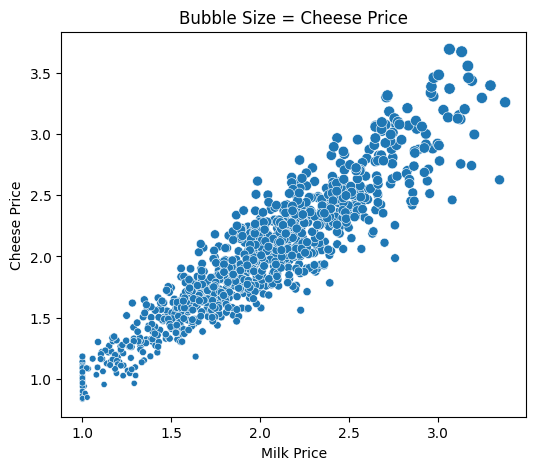

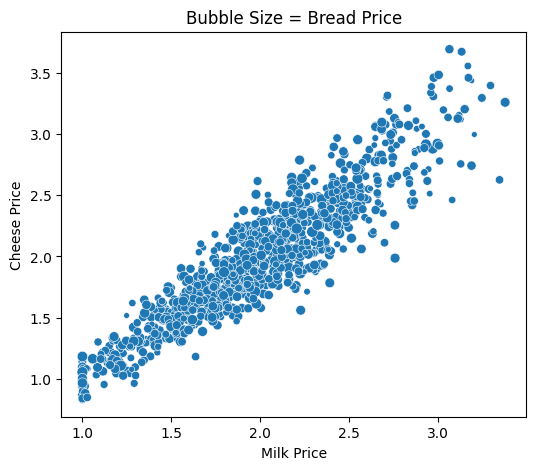

In [31]:
# helper function normalize size scaling
def scale_sizes(series, maxbubble=300):
    return (series / series.max()) * maxbubble

# 1. bubble size = milk price
plt.figure(figsize=(6, 5))
sns.scatterplot(data=df3, x="milk", y="cheese", size=scale_sizes(df3["milk"]), legend=False)
plt.title("Bubble Size = Milk Price")
plt.xlabel("Milk Price")
plt.ylabel("Cheese Price")
plt.show()

# 2. bubble size = cheese price
plt.figure(figsize=(6, 5))
sns.scatterplot(data=df3, x="milk", y="cheese", size=scale_sizes(df3["cheese"]), legend=False)
plt.title("Bubble Size = Cheese Price")
plt.xlabel("Milk Price")
plt.ylabel("Cheese Price")
plt.show()

# 3. bubble size = bread price
plt.figure(figsize=(6, 5))
sns.scatterplot(data=df3, x="milk", y="cheese", size=scale_sizes(df3["bread"]), legend=False)
plt.title("Bubble Size = Bread Price")
plt.xlabel("Milk Price")
plt.ylabel("Cheese Price")
plt.show()


### Answer
#### Among these three bubble plots, the plot where bubble size represents bread price is the most informative because it adds a third, independent variable to the milk vs. cheese relationship, telling us that bread price is uncorrelated with the others. Whereas using the bubble size for milk or cheese is redundant since those values are already shown on the x and y axes, respectively, offering no new insight and potentially misleading viewers by visually amplifying what’s already encoded in position.

### Principal component analysis

Perform a principal component analysis of the data.  What are the first, second, and third component vectors?

Challenge question: explain why the three vectors point as they do.  (Could someone have guessed the order of the three vectors, even before running the analysis?)

In [33]:

# select the features
X = df3[["milk", "cheese", "bread"]]

# perform PCA
pca = decomposition.PCA(n_components=3)
pca.fit(X)

# Show explained variance and component vectors
print("Explained variance ratio:", pca.explained_variance_ratio_)
print("Principal components:\n", pca.components_)


Explained variance ratio: [0.63748768 0.34861425 0.01389806]
Principal components:
 [[-0.03825586 -0.03809452  0.99854158]
 [ 0.67873842  0.73239615  0.05394468]
 [ 0.73338301 -0.67981224  0.00216223]]


### Answer
#### Since milk and cheese are strongly correlated, we’d expect PC2 to capture their combined movement. Since bread is uncorrelated with both, it should dominate its own principal component (PC1), and since it varies independently, it explains the most variance. PC3 naturally ends up orthogonal to both 1 and 2, capturing the small residual variation between milk and cheese. So the PCA structure aligns exactly with the correlation logic. Yes, we can predict this before running the pCA analysis.

### Linear regression

Use linear regression to predict the milk price from the other two, the cheese price from the other two, and the bread price from the other two.  Which prediction(s) work the best, and why?

In [35]:
results = {}

# milk, from cheese and bread
model_milk = linear_model.LinearRegression()
model_milk.fit(df3[["cheese", "bread"]], df3["milk"])
pred_milk = model_milk.predict(df3[["cheese", "bread"]])
results["milk"] = {
    "mse": mean_squared_error(df3["milk"], pred_milk),
    "corr": np.corrcoef(df3["milk"], pred_milk)[0, 1]
}

# cheese, from milk and bread
model_cheese = linear_model.LinearRegression()
model_cheese.fit(df3[["milk", "bread"]], df3["cheese"])
pred_cheese = model_cheese.predict(df3[["milk", "bread"]])
results["cheese"] = {
    "mse": mean_squared_error(df3["cheese"], pred_cheese),
    "corr": np.corrcoef(df3["cheese"], pred_cheese)[0, 1]
}

# predict bread, from milk and cheese
model_bread = linear_model.LinearRegression()
model_bread.fit(df3[["milk", "cheese"]], df3["bread"])
pred_bread = model_bread.predict(df3[["milk", "cheese"]])
results["bread"] = {
    "mse": mean_squared_error(df3["bread"], pred_bread),
    "corr": np.corrcoef(df3["bread"], pred_bread)[0, 1]
}

# show results
for target, metrics in results.items():
    print(f"{target.upper()} → MSE: {metrics['mse']:.4f}, Correlation: {metrics['corr']:.4f}")


MILK → MSE: 0.0345, Correlation: 0.9231
CHEESE → MSE: 0.0397, Correlation: 0.9231
BREAD → MSE: 0.8773, Correlation: 0.0360


### Answer 
#### the linear regression is very effective at predicting milk and cheese prices from the other two variables, with strong correlations (~0.92) and low MSEs. This is expected because milk and cheese are highly correlated with one another. But the model can't predict bread price well, with a near-zero correlation and much higher error, showing us that bread is statistically independent from milk and cheese in the dataset. Therefore, only the milk–cheese pair benefits from regression modeling in this context.

# 4. Storytelling With Data plot



Reproduce any graph of your choice in p. 120-135 of the Storytelling With Data book as best you can.  ("Use color consistently" in chapter four up to "Create a clear visual hierarchy of information" in chapter five.)    You do not have to get the exact data values right, just the overall look and feel.

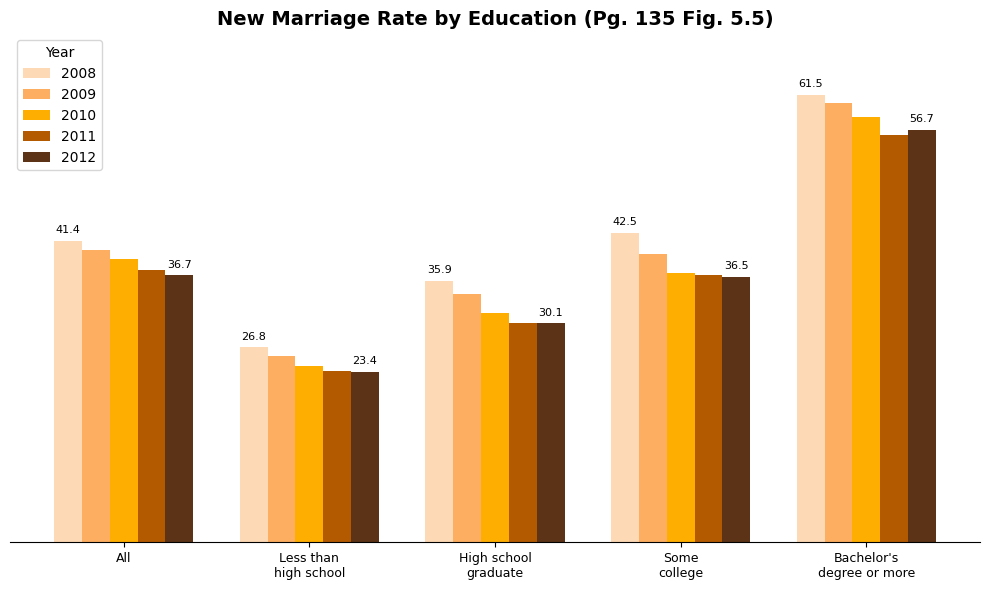

In [23]:
# graph on page 135 figure 5.5

# categories and years
education_levels = [
    "All",
    "Less than\nhigh school",
    "High school\ngraduate",
    "Some\ncollege",
    "Bachelor's\ndegree or more"
]

years = ['2008', '2009', '2010', '2011', '2012']
colors = ['#fdd9b5', '#fdae61', '#fdae00', '#b35900', '#5c3317']

# rows = education levels, columns = years
data = [
    [41.4, 40.2, 38.9, 37.4, 36.7],
    [26.8, 25.6, 24.2, 23.5, 23.4],
    [35.9, 34.1, 31.6, 30.2, 30.1],
    [42.5, 39.6, 37.1, 36.7, 36.5],
    [61.5, 60.4, 58.5, 56.0, 56.7]
]

# convert to numpy array for convenience
data = np.array(data)

# plot setup
fig, ax = plt.subplots(figsize=(10, 6))

bar_width = 0.15
index = np.arange(len(education_levels))

# plot bars for each year yuh
for i, year in enumerate(years):
    ax.bar(index + i * bar_width, data[:, i], bar_width, label=year, color=colors[i])

# formatting and stuff
ax.set_title("New Marriage Rate by Education (Pg. 135 Fig. 5.5)", fontsize=14, weight='bold')
ax.set_ylabel("Newly married adults per 1,000 eligible adults", fontsize=10)
ax.set_xticks(index + 2 * bar_width)
ax.set_xticklabels(education_levels, fontsize=9)
ax.legend(title='Year')
ax.set_ylim(0, 70)

# rmove all spines except bottom
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)
ax.spines['left'].set_visible(False)
ax.spines['bottom'].set_linewidth(0.8)

# Remove y-axis spine entirely
ax.spines['left'].set_visible(False)
ax.yaxis.set_visible(False)
ax.grid(False)
# remove y-axis ticks
ax.tick_params(axis='y', left=False)


# annotate the last bars
for i, value in enumerate(data[:, 4]):
    x_pos = index[i] + 4 * bar_width
    ax.text(x_pos, value + 0.8, f"{value:.1f}", ha='center', va='bottom', fontsize=8)
# annotate the first bars with values
for i, value in enumerate(data[:, 0]):
    x_pos = index[i] + 0 * bar_width
    ax.text(x_pos, value + 0.8, f"{value:.1f}", ha='center', va='bottom', fontsize=8)

plt.tight_layout()
plt.show()
